--- ACCURACY TEST (Single Component K=1) ---
 Quantile  Exact (stdtrit)  Root Method  MC (1M Samples)  MC (10M Samples)  Root Abs Error  MC(10M) Abs Error
    0.001        -6.340144    -6.340144        -6.276078         -6.323920             0.0           0.016224
    0.010        -2.547395    -2.547395        -2.543638         -2.539069             0.0           0.008326
    0.025        -1.355873    -1.355873        -1.348678         -1.353187             0.0           0.002686
    0.500         2.500000     2.500000         2.500358          2.500248             0.0           0.000248
    0.975         6.355873     6.355873         6.345939          6.353948             0.0           0.001924
    0.990         7.547395     7.547395         7.542313          7.542372             0.0           0.005023
    0.999        11.340144    11.340144        11.454963         11.322506             0.0           0.017639


--- PERFORMANCE STRESS TEST (Varying K Components, 5 Replications) ---
 K

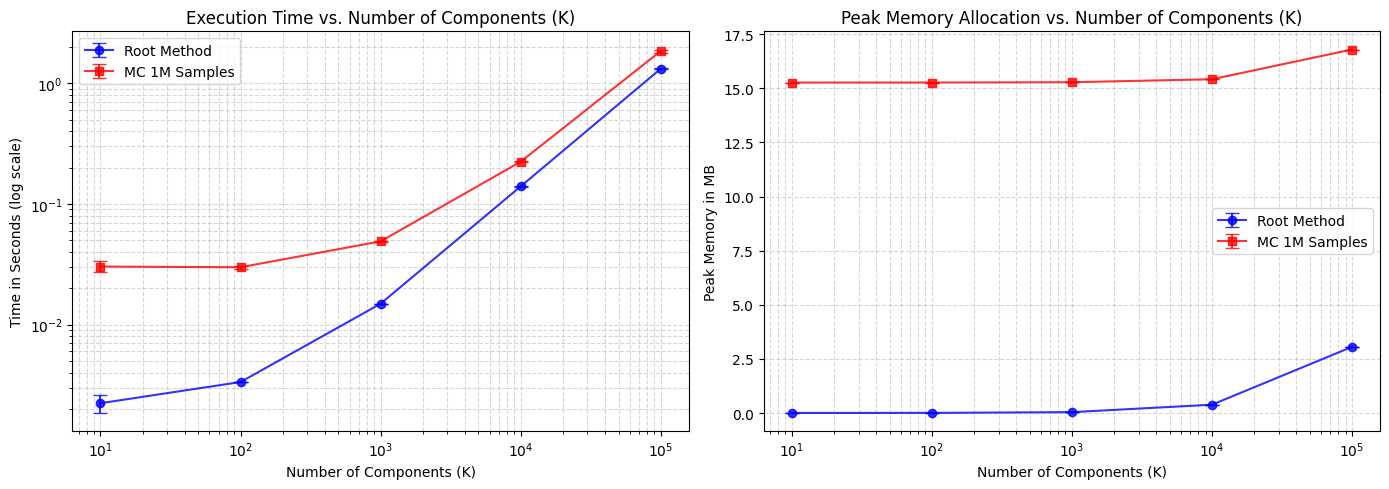

In [1]:
import sys
sys.path.append("../")

import numpy as np
import pandas as pd
import time
import tracemalloc
import gc
import matplotlib.pyplot as plt
from scipy.special import stdtrit
from rashomon.quantiles import q_mixture_t_root, q_mixture_t_mc

# =====================================================================
# 1. ACCURACY TEST (Single Component)
# =====================================================================
def test_accuracy():
    print("--- ACCURACY TEST (Single Component K=1) ---")
    k = 1
    w = [1.0]
    mu = [2.5]
    s = [1.5]
    df = [5.0]
    prob = np.array([0.001, 0.01, 0.025, 0.5, 0.975, 0.99, 0.999])

    # Ground Truth using exact analytical inverse CDF
    exact_q = mu[0] + s[0] * stdtrit(df[0], prob)

    # Root Method
    root_q = q_mixture_t_root(k, w, mu, s, df, prob)

    # Monte Carlo Method (Testing standard 1M and heavy 10M)
    mc_1m_q = q_mixture_t_mc(k, w, mu, s, df, prob, n_samples=1_000_000, seed=42)
    mc_10m_q = q_mixture_t_mc(k, w, mu, s, df, prob, n_samples=10_000_000, seed=42)

    df_acc = pd.DataFrame({
        "Quantile": prob,
        "Exact (stdtrit)": exact_q,
        "Root Method": root_q,
        "MC (1M Samples)": mc_1m_q,
        "MC (10M Samples)": mc_10m_q,
        "Root Abs Error": np.abs(exact_q - root_q),
        "MC(10M) Abs Error": np.abs(exact_q - mc_10m_q)
    })
    print(df_acc.to_string(index=False))
    print("\n")


# =====================================================================
# 2. PERFORMANCE STRESS TEST (Varying K)
# =====================================================================
def profile_function(func, *args, **kwargs):
    """Profiles a single function call for time and peak memory."""
    # Force garbage collection to ensure pristine memory state before tracking
    gc.collect()

    tracemalloc.start()
    start_time = time.perf_counter()

    func(*args, **kwargs)

    end_time = time.perf_counter()
    _, peak_memory = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    return end_time - start_time, peak_memory / (1024 * 1024) # Convert to MB

def test_scaling(n_replications=5):
    print(f"--- PERFORMANCE STRESS TEST (Varying K Components, {n_replications} Replications) ---")
    k_values = [10, 100, 1000, 10000, 100000] # Logarithmic scale for K
    prob = np.array([0.0001, 0.001, 0.01, 0.5, 0.99, 0.999, 0.9999]) # Extreme tail quantiles

    results = []

    for k in k_values:
        # Generate random mixture parameters (kept static across replications for fairness)
        np.random.seed(42)
        w = np.random.dirichlet(np.ones(k))
        mu = np.random.normal(0, 5, k)
        s = np.random.uniform(0.5, 2.0, k)
        df = np.random.uniform(3, 30, k)

        root_times, root_mems = [], []
        mc_times, mc_mems = [], []

        for _ in range(n_replications):
            # Profile Root Method
            t_root, mem_root = profile_function(q_mixture_t_root, k, w, mu, s, df, prob)
            root_times.append(t_root)
            root_mems.append(mem_root)

            # Profile MC Method (1M Samples)
            t_mc, mem_mc = profile_function(q_mixture_t_mc, k, w, mu, s, df, prob, n_samples=1_000_000)
            mc_times.append(t_mc)
            mc_mems.append(mem_mc)

        # Average the results and compute standard deviation
        results.append({
            "K Components": k,
            "Root Time (s)": np.mean(root_times),
            "Root Time Std": np.std(root_times),
            "Root Peak Mem (MB)": np.mean(root_mems),
            "Root Mem Std": np.std(root_mems),
            "MC Time (s)": np.mean(mc_times),
            "MC Time Std": np.std(mc_times),
            "MC Peak Mem (MB)": np.mean(mc_mems),
            "MC Mem Std": np.std(mc_mems)
        })

    df_perf = pd.DataFrame(results)
    print(df_perf.to_string(index=False))

    return df_perf

# =====================================================================
# 3. PLOTTING
# =====================================================================
def plot_results(df_perf):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Plot Time with Error Bars
    ax1.errorbar(df_perf["K Components"], df_perf["Root Time (s)"],
                 yerr=df_perf["Root Time Std"], fmt='-o', capsize=5,
                 label='Root Method', color='blue', alpha=0.8)

    ax1.errorbar(df_perf["K Components"], df_perf["MC Time (s)"],
                 yerr=df_perf["MC Time Std"], fmt='-s', capsize=5,
                 label='MC 1M Samples', color='red', alpha=0.8)

    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_title("Execution Time vs. Number of Components (K)")
    ax1.set_xlabel("Number of Components (K)")
    ax1.set_ylabel("Time in Seconds (log scale)")
    ax1.legend()
    ax1.grid(True, which="both", ls="--", alpha=0.5)

    # Plot Memory with Error Bars
    ax2.errorbar(df_perf["K Components"], df_perf["Root Peak Mem (MB)"],
                 yerr=df_perf["Root Mem Std"], fmt='-o', capsize=5,
                 label='Root Method', color='blue', alpha=0.8)

    ax2.errorbar(df_perf["K Components"], df_perf["MC Peak Mem (MB)"],
                 yerr=df_perf["MC Mem Std"], fmt='-s', capsize=5,
                 label='MC 1M Samples', color='red', alpha=0.8)

    ax2.set_xscale('log')
    # Not using log scale for memory because Root mem might be close to 0
    ax2.set_title("Peak Memory Allocation vs. Number of Components (K)")
    ax2.set_xlabel("Number of Components (K)")
    ax2.set_ylabel("Peak Memory in MB")
    ax2.legend()
    ax2.grid(True, which="both", ls="--", alpha=0.5)

    plt.tight_layout()
    plt.savefig('bma_quantile_benchmark.png', dpi=300)
    print("\nPlot saved successfully as 'bma_quantile_benchmark.png'")

if __name__ == "__main__":
    test_accuracy()
    df_performance = test_scaling(n_replications=5)
    plot_results(df_performance)